<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">AG Dynamics of the Earth</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Juypter notebooks</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
</tr>
</table>

# Machine learning: Preparing the data set
----
*Georg Kaufmann,
Geophysics Section,
Institute of Geological Sciences,
Freie Universität Berlin,
Germany*

We now look at the dataset and try to identify errors in the set.

First, load some `python` libraries and import the `iris data set` as `pandas` data frame `df`:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('data/iris_dirty.csv',
                 header=None,
                 encoding='iso-8859-15',
                 names=['sepal length', 'sepal width', 'petal length', 'petal width', 'class'])

Note, that the data set does not have a header line. We therefor manually add a header for
easier identificaion later...

Next, type first 10 lines:

In [3]:
df.head(10)

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,2 mm,Iris-setosa
1,4.9,3.0,1.4,2 mm,Iris-setosa
2,4.7,3.2,1.3,2 mm,Iris-setosa
3,4.6,3.1,1.5,2 mm,Iris-setosa
4,5.0,3.6,1.4,2 mm,Iris-setosa
5,5.4,3.9,1.7,4 mm,Iris-setosa
6,4.6,3.4,1.4,3 mm,Iris-setosa
7,5.0,3.4,1.5,2 mm,Iris-setosa
8,4.4,2.9,1.4,2 mm,Iris-setosa
9,4.9,3.1,1.5,1 mm,Iris-setosa


It seems that speal length, sepal width, and petal length are in **cm**, but the petal width in **mm**,
with the label added (Needs to be changed later).

### Identify and then fill missing values

Next, check the number of lines in the data set: 

In [4]:
df.count()

sepal length    151
sepal width     150
petal length    151
petal width     151
class           151
dtype: int64

We have 3 times 50 record, plus the header, makes 101 lines. Seems, that for the **sepal width**, an entry
is missing.

Check, which record of the **sepal width** has no number in:

In [5]:
df[df['sepal width'].isnull()]

,sepal length,sepal width,petal length,petal width,class
82,5.8,NaN,3.9,12 mm,Iris-versicolor


It record line 82.

In [6]:
meanSepalWidth=pd.Series.mean(df[df['class']  == 'Iris-versicolor']['sepal width'])
print(meanSepalWidth)

2.7800000000000007


In [7]:
df.loc[82]

sepal length                5.8
sepal width                 NaN
petal length                3.9
petal width               12 mm
class           Iris-versicolor
Name: 82, dtype: object

In [8]:
df.loc[82,'sepal width'] = meanSepalWidth

In [9]:
df.loc[82]

sepal length                5.8
sepal width                2.78
petal length                3.9
petal width               12 mm
class           Iris-versicolor
Name: 82, dtype: object

... done

### Identify double lines

In [10]:
df[df.duplicated(keep=False)]

,sepal length,sepal width,petal length,petal width,class
9,4.9,3.1,1.5,1 mm,Iris-setosa
34,4.9,3.1,1.5,1 mm,Iris-setosa
37,4.9,3.1,1.5,1 mm,Iris-setosa
50,7.0,3.2,4.7,14 mm,Iris-versicolor
100,7.0,3.2,4.7,14 mm,Iris-versicolor


In [11]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,49,49,49,49
Iris-setsoa,1,1,1,1
Iris-versicolor,51,51,51,51
Iris-virginica,50,50,50,50


In [12]:
df = df.drop(df.index[[100]])

In [13]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,49,49,49,49
Iris-setsoa,1,1,1,1
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


... done

### Correct typo for class

In [14]:
df[df['class']  == 'Iris-setsoa']

,sepal length,sepal width,petal length,petal width,class
49,5.0,3.3,1.4,2 mm,Iris-setsoa


In [15]:
df.loc[49,'class'] = 'Iris-setosa'

In [16]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


... done

### Change petal width to cm

In [17]:
pd.to_numeric('2 mm'.replace(' mm', '')) / 10

0.2

In [18]:
def convert_from_mm(row):
    return pd.to_numeric(row['petal width'].replace(' mm', '')) / 10

In [19]:
df['petal width'] = df.apply(convert_from_mm, axis='columns')

In [20]:
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


... done

### Check for implausbile numbers and correct

In [21]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,6.191333,3.054533,3.758667,1.198667
std,4.338310,0.433205,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,58.000000,4.400000,6.900000,2.500000


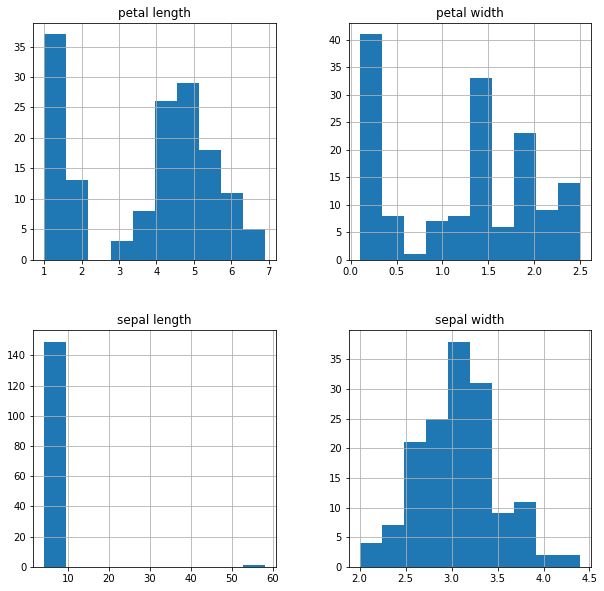

In [22]:
df.hist(figsize=(10, 10))
plt.show()

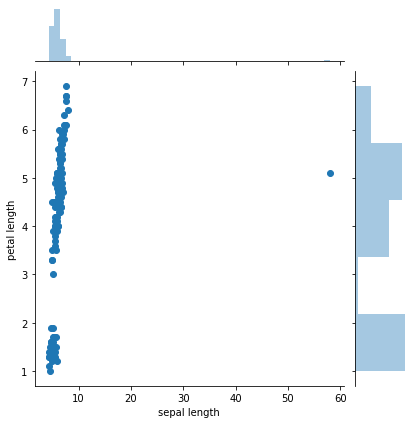

In [23]:
sns.jointplot(df['sepal length'], df['petal length'])
plt.show()

In [24]:
df[df['sepal length'] == 58]

,sepal length,sepal width,petal length,petal width,class
143,58.0,2.7,5.1,1.9,Iris-virginica


In [25]:
df.loc[143,'sepal length'] = 5.8

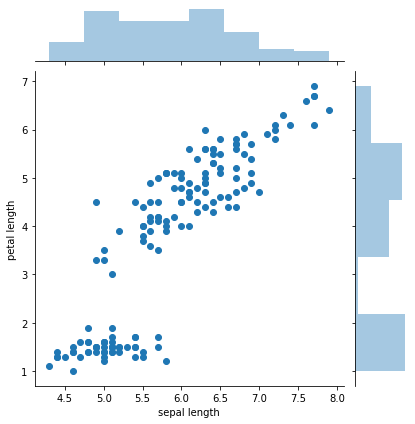

In [26]:
sns.jointplot(df['sepal length'], df['petal length'])
plt.show()

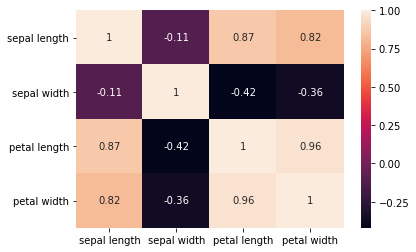

In [27]:
corrmat = df.corr()
sns.heatmap(corrmat, annot=True)
plt.show()

In [28]:
df.to_csv('data/iris_cleaned.csv', index=False, header=True)

[next>](03_iris3.ipynb)